# Trotterisation of Transverse Field Ising Model (TFIM) time evolution

Here, we will simulate the transverse field ising model as show in the slides:

<img src="./images/tfim_circuit.png" alt="TFIM" width="600"/>


In [1]:
# Parameters
h = 10.0
J_01 = 10.0
J_12 = 10.0
J_02 = 10.0

evolution_time = 10.0
num_observable_points = 30

delta_t = evolution_time / num_observable_points

The observable we want to measure is the Z magnetization. This is just the sum over Pauli Z operators.

In [2]:
# Needed imports
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp

# Create a SparsePauliOp for the observable
observable = SparsePauliOp.from_list([("ZII", 1), ("IZI", 1), ("IIZ", 1)])

print(observable)

SparsePauliOp(['ZII', 'IZI', 'IIZ'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j])


For Trotterization, we are splitting the time evolution into several steps.


In [3]:
num_trotter_steps = 5

# Time per Trotter step
delta_tau = delta_t / num_trotter_steps

As seen in the diagram, the circuit has six unitaries. Let us begin with the three X terms.

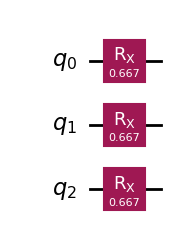

In [4]:
x_field_circuit = QuantumCircuit(3)
x_field_circuit.rx(h * delta_tau, 0)
x_field_circuit.rx(h * delta_tau, 1)
x_field_circuit.rx(h * delta_tau, 2)

x_field_circuit.draw("mpl")

Now, let's address the Z two-qubit terms.

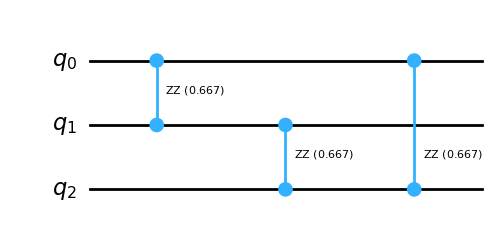

In [5]:
z_terms_circuit = QuantumCircuit(3)
z_terms_circuit.rzz(J_01 * delta_tau, 0, 1)
z_terms_circuit.rzz(J_12 * delta_tau, 1, 2)
z_terms_circuit.rzz(J_02 * delta_tau, 0, 2)

z_terms_circuit.draw("mpl")

Now, we combine to create a single Trotter step.

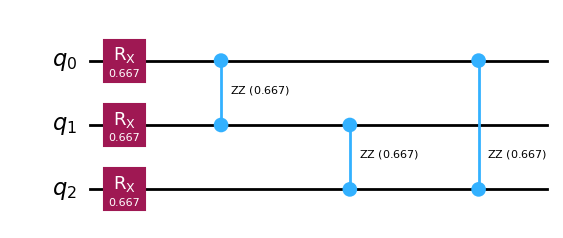

In [6]:
single_trotter_step_circuit = x_field_circuit.compose(z_terms_circuit)
single_trotter_step_circuit.draw("mpl")

Now, we need to repeat this circuit for the number of Trotter steps needed.

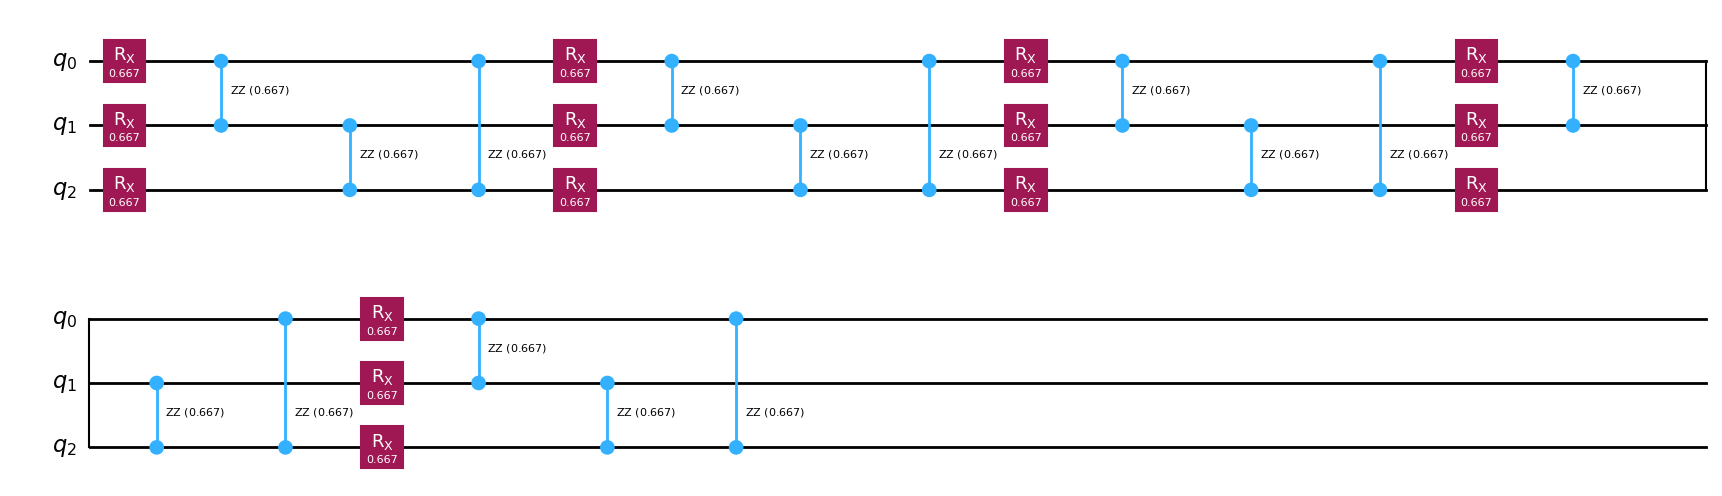

In [7]:
single_time_point_circuit = QuantumCircuit(3)
for _ in range(num_trotter_steps):
    single_time_point_circuit = single_time_point_circuit.compose(single_trotter_step_circuit)

single_time_point_circuit.draw("mpl")

Let's run the quantum circuit, using the estimator.

In [8]:
from qiskit.primitives import StatevectorEstimator

# Instantiate an estimator
estim = StatevectorEstimator()


# Evaluate exp. val. of X on qubit 0, Z on qubit 1
pub = (single_time_point_circuit, [observable]) # Primitive Unit Bloc (PUB): a tuple of (circuit, observables)
job = estim.run([pub])

# Fetch exp. val.
print(job.result()[0].data.evs)

[2.10228624]


This gives us the Z Magnitization for just one time point, with each time point compose of multiple Trotter steps. We need the value for all of the time points.

In [9]:
# Create a list of pubs for all time points
pubs = []

for i in range(num_observable_points):
    current_circuit = single_time_point_circuit.repeat(i)
    pubs.append((current_circuit, [observable]))

# Run the estimator on all pubs
job = estim.run(pubs)


Now, we will get the data and plot the results

In [10]:
# Extract exp. vals. for all time points
exp_vals = [res.data.evs[0] for res in job.result()]

print(exp_vals)

[np.float64(3.0), np.float64(2.102286235865296), np.float64(-0.026873314657200442), np.float64(-2.055342232087658), np.float64(-2.73162866896951), np.float64(-1.6788276413357686), np.float64(0.3743193478099913), np.float64(2.0715312624436057), np.float64(2.3072607746957248), np.float64(0.9396821383372743), np.float64(-1.1200792902848198), np.float64(-2.499412114673582), np.float64(-2.2552915321048355), np.float64(-0.49084637192075853), np.float64(1.7006423308771952), np.float64(2.930278991384619), np.float64(2.4020024436158582), np.float64(0.4250261982661845), np.float64(-1.7790444551107618), np.float64(-2.8516008370531676), np.float64(-2.1586723990411842), np.float64(-0.18753331102480136), np.float64(1.7743905275379177), np.float64(2.470495646379262), np.float64(1.481357426273791), np.float64(-0.511261076950918), np.float64(-2.1712351656876505), np.float64(-2.3770061662009114), np.float64(-0.9524618396092372), np.float64(1.211630286430016)]


Text(0, 0.5, 'Z Magnetization')

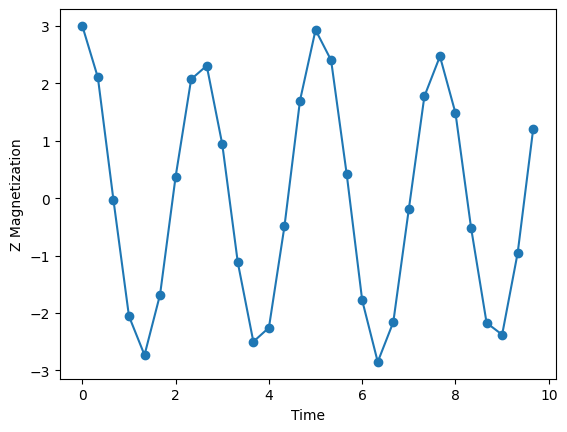

In [11]:
# Plotting
import matplotlib.pyplot as plt
time_points = [i * delta_t for i in range(num_observable_points)]
plt.plot(time_points, exp_vals, linestyle="-", marker="o")
plt.xlabel("Time")
plt.ylabel("Z Magnetization")

## Exercises

1. What happens if you increase the number of Trotter steps?
1. Decrease them?
1. Converge the simulation with respect to the number of Trotter steps.
1. Try different parameters for the Hamiltonian. Are the simulations of some parameters easier to simulate than others?
1. Perform Trotter for the Heisenberg Hamiltonian of notebook 2 by adding the XX and YY terms to the current simulation. Be sure to keep the transverse field (single-qubit X terms).

# 